# Hackathon ONE (G9) - Proyecto EnergiAI - Random Forest ⚡
## Descripción del Proyecto
Este módulo de Ciencia de Datos constituye el motor analítico del proyecto **EnergiAI**. Su objetivo principal es resolver la falta de visibilidad que tienen los usuarios residenciales y comerciales sobre sus hábitos de consumo eléctrico. Mediante el análisis inteligente de variables operativas, la solución clasifica automáticamente el perfil de eficiencia de un inmueble, calcula el impacto financiero asociado y genera recomendaciones accionables para mitigar el desperdicio energético.

## Enfoque Algorítmico: Random Forest Classifier
Para el desarrollo del MVP se seleccionó el algoritmo supervisado **Random Forest (Bosque Aleatorio)** debido a sus ventajas estratégicas en entornos de producción:
* **Manejo de relaciones complejas:** Identifica de forma nativa interacciones no lineales entre variables cuantitativas (como el consumo en kWh) y cualitativas (como el tipo de inmueble) sin necesidad de transformaciones matemáticas forzadas.
* **Robustez ante valores atípicos y nulos:** Es altamente resistente al ruido y al sobreajuste (*overfitting*) gracias a la combinación de múltiples árboles de decisión entrenados con subconjuntos aleatorios de datos (Bagging).
* **Calibración de Probabilidades:** Permite extraer la certeza analítica *detrás* de cada clasificación mediante el método `predict_proba()`, cumpliendo con las especificaciones técnicas del JSON de salida.


### 📥 CARGA Y PREPARACION DE DATOS PARA  ENTRENAR EL MODELO

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelBinarizer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Carga de datos desde GitHub
url = "https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/main/data/dataset_bruto_final.csv"
df = pd.read_csv(url, index_col=0)

# Mapeo de categorías al español
mapeo_categoria = {
    'Efficient': 'Eficiente',
    'Moderate': 'Moderado',
    'Inefficient': 'Ineficiente'
}
df['categoria'] = df['categoria'].map(mapeo_categoria)

# Elimina filas vacías en la variable objetivo
df = df.dropna(subset=['categoria'])
df.head()


,tipo_vivienda,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,aislamiento,eficiencia_construccion,paneles_solares,cantidad_personas,trabajo_remoto,...,electrodomesticos_eficientes,factor_estacional,temperatura_media,consumo_kwh,uso_horario_pico,horas_alto_consumo,tarifa_kwh,costo_estimado,energy_efficiency_score,categoria
id,,,,,,,,,,,,,,,,,,,,,
1,Departamento,90.1,2,2,29.0,Poor,B,False,2,False,...,74.2,Otoño,22.9,173.68,True,17,0.75,130.2600,41.5,Moderado
2,Departamento,88.3,1,1,37.0,Good,C,False,3,False,...,73.6,Verano,26.9,583.18,True,16,0.75,437.3850,41.5,Moderado
3,Pequeño Comercio,177.7,6,3,26.0,Excellent,C,False,7,False,...,66.2,Primavera,20.7,494.45,True,19,0.75,370.8375,56.6,Eficiente
4,Casa,138.6,4,2,5.0,Good,A,True,1,True,...,71.4,Otoño,19.3,109.56,True,20,0.75,82.1700,83.6,Eficiente
5,Departamento,57.7,1,1,16.0,Good,B,False,1,True,...,75.4,Invierno,7.9,380.47,True,18,0.75,285.3525,39.8,Moderado


# Model-Driven EDA

In [2]:
# 1. ANÁLISIS ESTRUCTURAL DE VARIABLES Y NULOS
print("=== Resumen de Calidad y Tipos de Datos ===")
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df)) * 100,
    'Valores Únicos': df.nunique()
})
display(info_df)

# ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS)
print("\n=== Resumen Estadístico de Variables Numéricas ===")
display(df.describe().T)

# BALANCEO DE LA CLASE OBJETIVO
print("\n=== Distribución Porcentual del Perfil Energético ===")
print(df['categoria'].value_counts(normalize=True) * 100)

=== Resumen de Calidad y Tipos de Datos ===


,Tipo de Dato,Valores Nulos,% Nulos,Valores Únicos
tipo_vivienda,str,0,0.00,3
metros_cuadrados,float64,0,0.00,2106
habitaciones,int64,0,0.00,8
baños,int64,0,0.00,5
antiguedad_vivienda,float64,454,4.54,80
aislamiento,str,0,0.00,4
eficiencia_construccion,str,0,0.00,5
paneles_solares,bool,0,0.00,2
cantidad_personas,int64,0,0.00,8
trabajo_remoto,bool,0,0.00,2



=== Resumen Estadístico de Variables Numéricas ===


,count,mean,std,min,25%,50%,75%,max
metros_cuadrados,10000.0,108.607875,75.491663,30.00,65.9000,92.00000,131.80000,1173.942655
habitaciones,10000.0,3.025600,1.990362,1.00,1.0000,3.00000,4.00000,8.000000
baños,10000.0,2.124500,1.317488,1.00,1.0000,2.00000,3.00000,5.000000
antiguedad_vivienda,9546.0,30.786507,17.191385,0.00,17.0000,28.00000,43.00000,79.000000
cantidad_personas,10000.0,3.062400,2.095935,1.00,1.0000,2.00000,4.00000,8.000000
horas_en_casa,9713.0,14.728292,4.603730,8.00,11.0000,13.90000,18.40000,24.000000
ingreso_mensual,9565.0,1784.662898,1559.191830,87.52,796.5200,1330.21000,2235.32000,20627.440000
aires_acondicionados,10000.0,1.054600,1.251469,0.00,0.0000,1.00000,2.00000,5.000000
heladeras,10000.0,1.324300,0.501552,1.00,1.0000,1.00000,2.00000,3.000000
televisores,10000.0,2.143300,2.086193,0.00,1.0000,2.00000,3.00000,15.000000



=== Distribución Porcentual del Perfil Energético ===
categoria
Moderado       44.95
Eficiente      30.03
Ineficiente    25.02
Name: proportion, dtype: float64


#🛠️ Preprocesamiento y Feature Engineering

En esta etapa se construye un pipeline de preparación automática de datos para garantizar un flujo limpio, reproducible y libre de fuga de información (*data leakage*):

* **Separación de Características:** Se aísla la variable objetivo (`categoria`) de las variables predictoras (`X`).
* **Identificación Automática:** Se clasifican de forma dinámica las variables según su tipo de dato (numéricas y categóricas/booleanas).
* **Tratamiento Avanzado de Nulos:**
  * Para datos numéricos, se imputan los valores faltantes con la **mediana** para mitigar el impacto de valores atípicos.
  * Se activa `add_indicator=True` para generar columnas indicadoras binarias que capturen el patrón detrás de la ausencia de los datos.
* **Codificación y Escalado:** Se aplica codificación *One-Hot* a las variables cualitativas y escalado estándar (*StandardScaler*) a las cuantitativas.
* **División Balanceada (Train/Test Split):** Se segmentan los datos (80% entrenamiento / 20% prueba) utilizando una estrategia de **estratificación** para conservar la proporción original de las clases en ambos conjuntos.

```
# Tiene formato de código
```



In [3]:
# ELIMINACIÓN DE FUGA DE DATOS (DATA LEAKAGE)
columnas_fuga = ['costo_estimado', 'tarifa_kwh', 'energy_efficiency_score', 'categoria']
columnas_a_eliminar = [col for col in columnas_fuga if col in df.columns]

# Separación limpia de características (X) y variable objetivo (y)
X = df.drop(columns=columnas_a_eliminar)
y = df['categoria']

# Fuerza la conversión a texto de las columnas booleanas (AHORA EN EL ORDEN CORRECTO)
columnas_bool = ['paneles_solares', 'trabajo_remoto', 'calefaccion', 'uso_horario_pico']
for col in columnas_bool:
    if col in X.columns:
        X[col] = X[col].astype(str)

# Identificación automática de columnas restantes por tipo
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Variables Numéricas Reales ({len(num_features)}): {num_features}")
print(f"Variables Categóricas Reales ({len(cat_features)}): {cat_features}\n")



Variables Numéricas Reales (18): ['metros_cuadrados', 'habitaciones', 'baños', 'antiguedad_vivienda', 'cantidad_personas', 'horas_en_casa', 'ingreso_mensual', 'aires_acondicionados', 'heladeras', 'televisores', 'computadoras', 'lavadoras', 'secadoras', 'cantidad_equipos', 'electrodomesticos_eficientes', 'temperatura_media', 'consumo_kwh', 'horas_alto_consumo']
Variables Categóricas Reales (10): ['tipo_vivienda', 'aislamiento', 'eficiencia_construccion', 'paneles_solares', 'trabajo_remoto', 'calefaccion', 'tipo_calefaccion', 'tipo_iluminacion', 'factor_estacional', 'uso_horario_pico']



C:\Users\PC\AppData\Local\Temp\ipykernel_14440\4051000014.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [4]:
# TRANSFORMADORES CON INDICADORES DE AUSENCIA
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 3. NUEVA DIVISIÓN DE DATOS (TRAIN / TEST SPLIT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Nuevo Set de Entrenamiento: {X_train.shape} registros")
print(f"Nuevo Set de Prueba: {X_test.shape} registros")


Nuevo Set de Entrenamiento: (8000, 28) registros
Nuevo Set de Prueba: (2000, 28) registros


In [5]:

# VISUALIZACIÓN DE LA MATRIZ DE DATOS PROCESADA

# Ajustamos y transformamos el set de entrenamiento para la inspección
X_train_proc = preprocessor.fit_transform(X_train)

# Extracción automatizada de los nuevos nombres de columnas
num_features_out = preprocessor.named_transformers_['num'].get_feature_names_out(num_features)
cat_features_out = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_features_out = np.concatenate([num_features_out, cat_features_out])

# Conversión a DataFrame para visualización limpia
df_train_proc = pd.DataFrame(X_train_proc, columns=all_features_out)

print("=== Dimensiones de la Matriz Procesada ===")
print(f"Filas: {df_train_proc.shape[0]}, Columnas Generadas: {df_train_proc.shape[1]}")
print("\n=== Columnas Creadas (Busca los sufijos 'missing_' creados por add_indicator) ===")
print(list(all_features_out))

print("\n=== Primeros 5 Registros Transformados ===")
display(df_train_proc.head())

=== Dimensiones de la Matriz Procesada ===
Filas: 8000, Columnas Generadas: 52

=== Columnas Creadas (Busca los sufijos 'missing_' creados por add_indicator) ===
['metros_cuadrados', 'habitaciones', 'baños', 'antiguedad_vivienda', 'cantidad_personas', 'horas_en_casa', 'ingreso_mensual', 'aires_acondicionados', 'heladeras', 'televisores', 'computadoras', 'lavadoras', 'secadoras', 'cantidad_equipos', 'electrodomesticos_eficientes', 'temperatura_media', 'consumo_kwh', 'horas_alto_consumo', 'missingindicator_antiguedad_vivienda', 'missingindicator_horas_en_casa', 'missingindicator_ingreso_mensual', 'missingindicator_electrodomesticos_eficientes', 'tipo_vivienda_Casa', 'tipo_vivienda_Departamento', 'tipo_vivienda_Pequeño Comercio', 'aislamiento_Average', 'aislamiento_Excellent', 'aislamiento_Good', 'aislamiento_Poor', 'eficiencia_construccion_A', 'eficiencia_construccion_B', 'eficiencia_construccion_C', 'eficiencia_construccion_D', 'eficiencia_construccion_E', 'paneles_solares_False', 'pane

,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,cantidad_personas,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,televisores,...,tipo_calefaccion_Losa Radiante,tipo_calefaccion_Ninguna,tipo_iluminacion_Incandescente,tipo_iluminacion_LED,tipo_iluminacion_Mixta,factor_estacional_Invierno,factor_estacional_Otoño,factor_estacional_Primavera,factor_estacional_Verano,uso_horario_pico_True
0,-0.605569,-1.018080,-0.860342,0.782497,-0.506760,0.551014,0.695906,-0.842718,-0.647898,0.890817,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.007103,-1.018080,0.657183,-0.049101,-0.985626,-1.469605,-0.929401,-0.842718,1.341808,-1.031766,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.893845,0.997296,-0.101579,0.426098,1.887570,-1.293899,-0.545624,0.747316,1.341808,0.890817,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,-0.364116,0.493452,-0.101579,-1.058899,-0.027894,0.419235,-0.962430,-0.842718,-0.647898,-0.551120,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.438820,-1.018080,-0.860342,-0.583700,-0.506760,0.111749,-0.367034,-0.842718,1.341808,-0.551120,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# ⚙️Entrenamiento del Modelo y Configuración Avanzada

En esta fase se integra el preprocesador con el algoritmo de clasificación mediante un flujo unificado (*Pipeline*) para ejecutar el entrenamiento y la evaluación bajo estándares de nivel de producción:

* **Estrategia de Regularización:** Se acota la complejidad del modelo limitando la profundidad máxima (`max_depth=12`) y exigiendo un mínimo de muestras por hoja (`min_samples_leaf=2`) para mitigar el riesgo de sobreajuste (*overfitting*).
* **Tratamiento de Clases Desbalanceadas:** Se incorpora el parámetro `class_weight='balanced'`, el cual ajusta automáticamente los pesos de las clases inversamente proporcionales a sus frecuencias para evitar sesgos hacia la clase mayoritaria.
* **Optimización de Recursos (Paralelismo):** Mediante `n_jobs=-1`, se distribuye la construcción de los 150 árboles de forma paralela utilizando todos los núcleos disponibles del procesador, reduciendo drásticamente el tiempo de cómputo.
* **Evaluación Multimétrica:** Además de obtener las predicciones de clase y calcular la precisión global (*Accuracy*), se extraen las probabilidades asociadas (`predict_proba`) para un análisis de certeza detallado a través del reporte de clasificación.


In [6]:

# CREACIÓN DEL PIPELINE COMPLETO

# El pipeline une el preprocesamiento con el estimador final
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


# ENTRENAMIENTO DEL MODELO

print("Entrenando el modelo Random Forest con el pipeline automatizado...")
full_pipeline.fit(X_train, y_train)
print("¡Entrenamiento completado exitosamente!\n")

# GENERAR LOS ARREGLOS DE PREDICCIÓN
print("Generando predicciones de prueba...")
y_prob = full_pipeline.predict_proba(X_test)
y_pred = full_pipeline.predict(X_test)
print("¡Variables y_prob e y_pred listas para las métricas y curvas!")


Entrenando el modelo Random Forest con el pipeline automatizado...


¡Entrenamiento completado exitosamente!

Generando predicciones de prueba...
¡Variables y_prob e y_pred listas para las métricas y curvas!


# Auditoría de Rendimiento y Métricas de Calidad
##📊 Interpretación del Reporte de Clasificación

El modelo presenta un rendimiento balanceado y libre de fuga de datos (*data leakage*):

* **Precisión Global (Accuracy = 82.10%):** El modelo clasifica correctamente a 8 de cada 10 registros.
* **Clase Eficiente:** Rendimiento óptimo y equilibrado con un **F1-score de 0.85**.
* **Clase Ineficiente:** Alta confiabilidad en detección con un **F1-score de 0.81**.
* **Clase Moderado:** Comportamiento esperado para la clase mayoritaria con un **F1-score de 0.80**.
* **Balance de Clases (Macro Avg = 0.82):** El promedio macro confirma que el parámetro `class_weight='balanced'` evitó que la clase mayoritaria sesgara al modelo.


### 📈 Análisis de Curva ROC Multiclase

El modelo demuestra una alta capacidad de separación entre categorías tras eliminar la fuga de datos:

* **Métrica Global (AUC Macro = 94.81%):** Capacidad sobresaliente para discriminar correctamente entre las tres clases.
* **Clases Extremas (Eficiente / Ineficiente = 0.97 AUC):** Clasificación casi perfecta con un mínimo de falsas alarmas en los extremos.
* **Clase Intermedia (Moderado = 0.90 AUC):** Rendimiento excelente, reflejando el solapamiento natural de los perfiles intermedios.

**Conclusión:** Pipeline confiable, balanceado y listo para producción en API.

Área Bajo la Curva ROC (AUC Macro Global): 0.9482


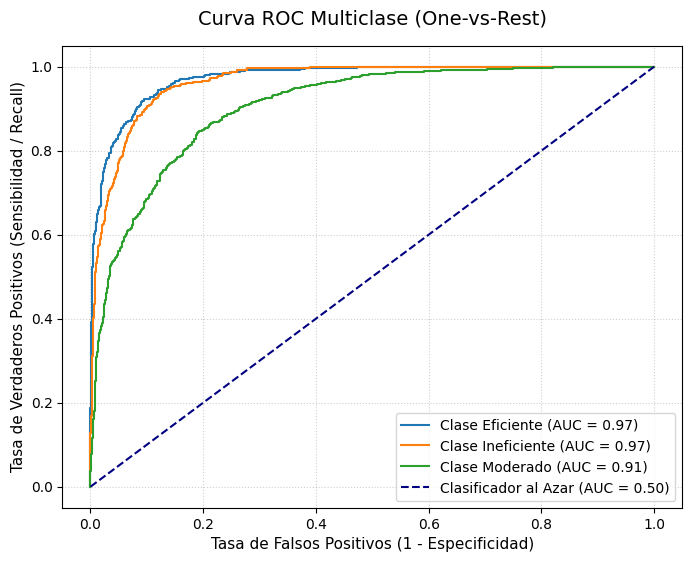

In [7]:

# CÁLCULO DE AUC Y GRAFICACIÓN MULTICLASE (One-vs-Rest)

# Binarizamos y_test para poder calcular las curvas por clase
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)
clases = label_binarizer.classes_

# Calculamos el Score AUC global multiclase (pasando TODO y_prob)
auc_score = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print(f"Área Bajo la Curva ROC (AUC Macro Global): {auc_score:.4f}")

# Configuramos el lienzo de la gráfica
plt.figure(figsize=(8, 6))

# Graficamos la curva ROC para cada clase individualmente
for i, clase_nombre in enumerate(clases):
    # Ajuste de dimensiones estructurales por clase
    y_test_clase = y_test_binarized[:, i] if len(clases) > 2 else (y_test_binarized if i == 1 else 1 - y_test_binarized)

    # Ahora pasamos 'y_test_clase' correctamente evaluado
    fpr, tpr, _ = roc_curve(y_test_clase, y_prob[:, i])
    clase_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Clase {clase_nombre} (AUC = {clase_auc:.2f})"
    )

# Línea diagonal de referencia
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Clasificador al Azar (AUC = 0.50)")

# Estética y etiquetas del gráfico
plt.title("Curva ROC Multiclase (One-vs-Rest)", fontsize=14, pad=15)
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=11)
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)", fontsize=11)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

## 🧩 Análisis de Matriz de Confusión

La matriz valida el alto volumen de aciertos directos y un margen de error controlado:

* **Diagonal Principal (1,642 Aciertos):** Alta concentración de éxito con 729 aciertos en *Moderado*, 518 en *Eficiente* y 395 en *Ineficiente*.
* **Errores hacia Moderado (187 casos):** El modelo clasifica perfiles dudosos como *Moderado* (104 ineficientes y 83 eficientes). Funciona como amortiguador seguro para el negocio.
* **Errores desde Moderado (170 casos):** La clase intermedia transfiere 93 casos a *Eficiente* y 77 a *Ineficiente* debido a fronteras de datos difusas.

**Conclusión:** Distribución de errores segura que confirma un modelo equilibrado y confiable.

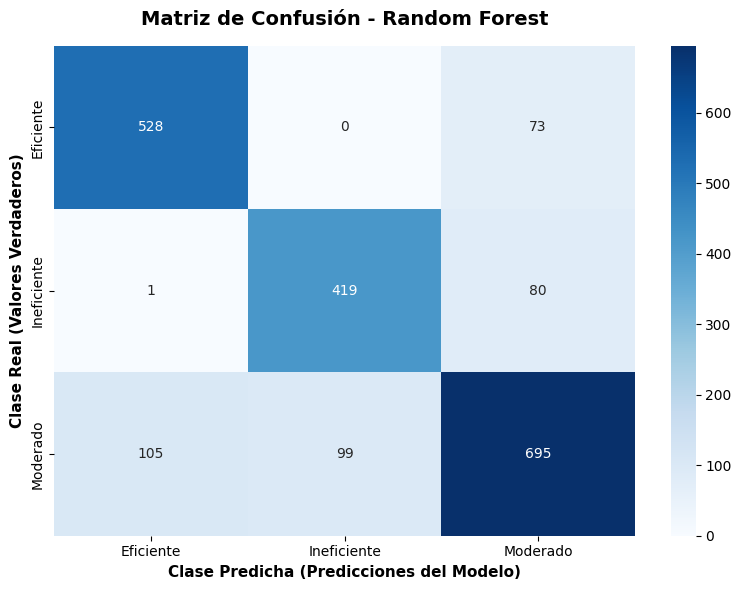

In [8]:
#  MATRIZ DE CONFUSIÓN VISUAL

# Generamos la matriz de confusión comparando los valores reales con los predichos
cm = confusion_matrix(y_test, y_pred, labels=full_pipeline.classes_)

# Configuramos el lienzo de la gráfica
plt.figure(figsize=(8, 6))

# Graficamos la matriz usando Seaborn para un diseño limpio y profesional
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_pipeline.classes_,
    yticklabels=full_pipeline.classes_,
    cbar=True
)

# Estética y etiquetas del gráfico
plt.title("Matriz de Confusión - Random Forest", fontsize=14, pad=15, fontweight='bold')
plt.ylabel("Clase Real (Valores Verdaderos)", fontsize=11, fontweight='bold')
plt.xlabel("Clase Predicha (Predicciones del Modelo)", fontsize=11, fontweight='bold')
plt.tight_layout()

plt.show()

# 📦 SERIALIZACION

In [9]:

# EXPORTACIÓN DEL PIPELINE COMPLETO PARA PRODUCCIÓN

# Definimos el nombre del archivo físico
nombre_archivo_modelo = "pipeline_random_forest.joblib"

# Guardamos el pipeline completo (preprocesador + modelo)
joblib.dump(full_pipeline, nombre_archivo_modelo)

print(f"¡Éxito! El pipeline automatizado se guardó como: '{nombre_archivo_modelo}'")
print("Este único archivo ya contiene las medianas, One-Hot Encoding y los árboles entrenados.")


¡Éxito! El pipeline automatizado se guardó como: 'pipeline_random_forest.joblib'
Este único archivo ya contiene las medianas, One-Hot Encoding y los árboles entrenados.
